In [ ]:
!nvidia-smi

Tue Sep 22 04:46:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# нужна для распаковки архива
!apt-get update -qq && apt-get install -y -qq zstd

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
# Установка Ollama
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [77]:
import subprocess, time

# Запускаем сервер
subprocess.Popen(["ollama", "serve"])
time.sleep(5)

# Проверяем, что отвечает
!curl -s http://localhost:11434/api/tags | head -c 200

{"models":[{"name":"qwen38-nothink:latest","model":"qwen38-nothink:latest","modified_at":"2026-09-22T06:22:03.406571107Z","size":13818690889,"digest":"a0e7dabd28f7bf0c161af856f73f4db6fccaa63c2b3e7bd3a

In [ ]:
!ollama pull smtek/Qwen3.8-27B:Q3_K_M-128k

In [ ]:
!pip install -q langextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.3/154.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.2 MB/s eta 0:00:00


In [ ]:
import langextract as lx
print(f"LangExtract версия: {lx.__version__ if hasattr(lx, '__version__') else 'установлен'}")

LangExtract версия: установлен


In [ ]:
from functools import partialmethod
from langextract.inference import OllamaLanguageModel

OllamaLanguageModel._ollama_query = partialmethod(
    OllamaLanguageModel._ollama_query,
    timeout=900,      # 15 минут — модель тяжёлая
    keep_alive=-1,
)

print("Патч применён: timeout=900, keep_alive=-1")

Патч применён: timeout=900, keep_alive=-1


In [ ]:
import pandas as pd
import re

# Загрузка
df = pd.read_csv("articles.csv")
df.columns = df.columns.str.strip()

# Оставляем только текст статьи
df = df.iloc[:, [1]].copy()
df.columns = ["article"]

# Минимальная очистка
def clean_text(text):
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)              # HTML-теги
    text = re.sub(r"https?://\S+", " ", text)         # ссылки
    text = re.sub(r"&nbsp;|&#8233;|&amp;", " ", text) # HTML-сущности
    text = re.sub(r"\s+", " ", text)                  # лишние пробелы
    return text.strip()

df["article"] = df["article"].apply(clean_text)

# Проверка
print(f"Всего текстов: {len(df)}")

Всего текстов: 49


In [68]:
prompt_v6 = """
Ты извлекаешь триплеты "субъект — предикат — объект" из русских новостных текстов.
Работай строго по правилам. Точность важнее полноты.

ПРАВИЛА:

1. СУБЪЕКТ — существительное или местоимение в ИМЕНИТЕЛЬНОМ падеже.
   ЗАПРЕЩЕНО:
   - Косвенные падежи ("модернизму", "для детей", "Россию").
   - Обстоятельства ("в Москве", "после работы").
   - Числа без существительного ("49%") — разверни до "49% респондентов".
   - Местоимения ("они", "его") — разверни по контексту.
   Если развернуть нельзя — пропусти.

2. ПРЕДИКАТ — глагол в ЛИЧНОЙ форме.
   ЗАПРЕЩЕНО:
   - Причастия: "признан", "зафиксирован", "заявлен", "выставлен", "занесён".
   - Модальные: "можно", "нельзя", "нужно", "важно", "необходимо".
   - Инфинитивы: "сохранить", "использовать".
   РАЗРЕШЕНО:
   - Личные: "считают", "вырос", "сообщил", "состоит", "является".
   - Связка "X — это Y": P="это".
   - Пассив "был выпущен", "были эвакуированы".

3. ОБЪЕКТ — именная группа, до 7 слов.
   ЗАПРЕЩЕНО в объекте:
   - Придаточные с "что", "как", "когда", "чтобы".
   - Целые клаузы: "забота состоит из умения".
   - Числа без существительного: "48 500".
   РАЗРЕШЕНО:
   - Именные группы: "забота", "нужные вещи".
   - Предложные группы с существительным: "о перебоях", "от жары", "на «Грэмми»", "в фильме".
   - Прилагательные и наречия, несущие факт: "комфортным регионом", "гарантией стабильности".
   Если объект длиннее 7 слов — обрежь до ядра + 1–2 зависимых слова.

4. ИСПОЛЬЗУЙ ГЛАГОЛ ИЗ ТЕКСТА.
   Если в тексте "состоит" — пиши "состоит". Не заменяй на "считают".

5. ПРОПУСТИ КЛАУЗУ, если:
   - Нет субъекта в именительном.
   - Нет личного глагола.
   - Объект — придаточная или целая клауза.
   - Это ВВОДНАЯ конструкция: "по данным", "как сообщил", "«Ведомости. Город» писал", "со ссылкой на", "с которым ознакомился".
   - Это РИТОРИЧЕСКИЙ вопрос.

Верни ТОЛЬКО JSON-массив без пояснений:
[{"subject": "...", "predicate": "...", "object": "..."}]
"""

In [ ]:
# ============ ПРИМЕР 1: числовой субъект + связка + обрезка ============
example_1 = lx.data.ExampleData(
    text="63% россиян считают, что забота — это стремление сделать жизнь партнёра проще.",
    extractions=[
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="63% россиян считают, что забота — это стремление сделать жизнь партнёра проще",
            attributes={"subject": "63% россиян", "predicate": "считают", "object": "забота"}
        ),
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="забота — это стремление сделать жизнь партнёра проще",
            attributes={"subject": "забота", "predicate": "это", "object": "стремление"}
        ),
    ]
)

# ============ ПРИМЕР 2: разворот местоимения + обрезка ============
example_2 = lx.data.ExampleData(
    text="Авторы отвечали на вопросы. Они чаще называют приготовление чая или кофе.",
    extractions=[
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="Авторы отвечали на вопросы",
            attributes={"subject": "авторы", "predicate": "отвечали", "object": "вопросы"}
        ),
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="Они чаще называют приготовление чая или кофе",
            attributes={"subject": "авторы", "predicate": "называют", "object": "приготовление чая"}
        ),
    ]
)

# ============ ПРИМЕР 3: длинный объект → обрезка до ядра ============
example_3 = lx.data.ExampleData(
    text="МЧС России эвакуировало 200 человек из зоны затопления в Курганской области.",
    extractions=[
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="МЧС России эвакуировало 200 человек из зоны затопления в Курганской области",
            attributes={"subject": "МЧС России", "predicate": "эвакуировало", "object": "200 человек"}
        ),
    ]
)

# ============ ПРИМЕР 4: причастие → пропустить ============
example_4 = lx.data.ExampleData(
    text="Копенгаген признан самым комфортным городом мира. Для детей предусмотрен отдельный городок.",
    extractions=[]
)
# "признан" — причастие → пропустить.
# "для детей" — дательный падеж → пропустить.

# ============ ПРИМЕР 5: прилагательное + модальное → пропустить ============
example_5 = lx.data.ExampleData(
    text="Июньская жара стала самой суровой. Монумент нельзя использовать.",
    extractions=[]
)
# "самой суровой" — прилагательное в объекте → пропустить.
# "нельзя" — не глагол → пропустить.

# ============ ПРИМЕР 6: предложные объекты → оставить ============
example_6 = lx.data.ExampleData(
    text="Бонни Тайлер номинировалась на «Грэмми». Она участвовала в конкурсах.",
    extractions=[
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="Бонни Тайлер номинировалась на «Грэмми»",
            attributes={"subject": "Бонни Тайлер", "predicate": "номинировалась", "object": "на «Грэмми»"}
        ),
        lx.data.Extraction(
            extraction_class="triplet",
            extraction_text="Она участвовала в конкурсах",
            attributes={"subject": "Бонни Тайлер", "predicate": "участвовала", "object": "в конкурсах"}
        ),
    ]
)

examples_v5 = [example_1, example_2, example_3, example_4, example_5, example_6]

In [ ]:
# проверка переменных
for v in ["prompt_v5", "examples_v5", "df", "lx"]:
    print(f"{v}: {'ok' if v in globals() else 'missing'}")

prompt_v5: ok
examples_v5: ok
df: ok
lx: ok


In [65]:
!ollama ps

NAME                             ID              SIZE     PROCESSOR    CONTEXT    UNTIL              
smtek/Qwen3.8-27B:Q3_K_M-128k    c41f01a675a8    13 GB    100% GPU     4096       2 minutes from now    


In [75]:
import requests, json, time

MODEL_ID = "smtek/Qwen3.8-27B:Q3_K_M-128k"

def extract_triplets(text):
    prompt = prompt_v6 + f"""

Верни результат ОДНИМ JSON-ОБЪЕКТОМ НА СТРОКУ, без массива:
{{"subject": "...", "predicate": "...", "object": "..."}}
{{"subject": "...", "predicate": "...", "object": "..."}}

Никаких [ ], запятых между строками, пояснений.

Текст:
{text}"""

    r = requests.post("http://localhost:11434/api/generate", json={
        "model": MODEL_ID,
        "prompt": prompt,
        "think": False,
        "stream": False,
        "options": {
            "num_ctx": 8192,
            "num_predict": 8192,
            "temperature": 0.0,
            "seed": 42
        }
    }, timeout=1800)

    raw = r.json().get("response", "")

    # Парсим построчно, переживаем битые строки
    triplets = []
    for line in raw.strip().split("\n"):
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]"):
            continue
        try:
            obj = json.loads(line)
            if isinstance(obj, dict) and "subject" in obj:
                triplets.append(obj)
        except:
            continue

    # Если ничего не получилось — пробуем как целый JSON
    if not triplets:
        try:
            data = json.loads(raw)
            if isinstance(data, list):
                return data
        except:
            pass
        return [{"error": "parse failed", "raw": raw[:500]}]

    return triplets

In [79]:
import os, json, time

OUTPUT_FILE = "triplets_qwen38_v6.jsonl"
if os.path.exists(OUTPUT_FILE):
    os.remove(OUTPUT_FILE)
    print("Старый файл удалён")

N_TEXTS = 10
start_all = time.time()

with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
    for i in range(N_TEXTS):
        text = df["article"].iloc[i]
        print(f"[{i+1}/{N_TEXTS}] text {i} (len={len(text)})...", end=" ")

        t0 = time.time()
        try:
            triplets = extract_triplets(text)
            elapsed = round(time.time() - t0, 1)

            if isinstance(triplets, list) and len(triplets) == 1 and "error" in triplets[0]:
                raise ValueError(triplets[0]["error"])

            record = {
                "text_index": i,
                "processing_time": elapsed,
                "num_triplets": len(triplets),
                "triplets": triplets,
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
            f.flush()
            print(f"{len(triplets)} triplets, {elapsed}s")
        except Exception as e:
            print(f"ERROR: {e}")
            f.write(json.dumps({"text_index": i, "error": str(e), "triplets": []}, ensure_ascii=False) + "\n")
            f.flush()

print(f"\nTotal: {(time.time() - start_all)/60:.1f} min")

Старый файл удалён
[1/10] text 0 (len=1571)... 17 triplets, 74.8s
[2/10] text 1 (len=1197)... 25 triplets, 93.4s
[3/10] text 2 (len=17554)... 102 triplets, 394.4s
[4/10] text 3 (len=1645)... 14 triplets, 68.8s
[5/10] text 4 (len=1799)... 15 triplets, 63.6s
[6/10] text 5 (len=4032)... 65 triplets, 264.6s
[7/10] text 6 (len=1453)... 9 triplets, 43.3s
[8/10] text 7 (len=7596)... 88 triplets, 343.0s
[9/10] text 8 (len=1976)... 12 triplets, 56.5s
[10/10] text 9 (len=2217)... 37 triplets, 158.8s

Total: 26.0 min


In [80]:
import json, pandas as pd

records = []
with open("triplets_qwen38_v6.jsonl", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

rows = []
for rec in records:
    for t in rec.get("triplets", []):
        if isinstance(t, dict) and "subject" in t:
            rows.append({
                "text_index": rec["text_index"],
                "subject": t.get("subject", ""),
                "predicate": t.get("predicate", ""),
                "object": t.get("object", ""),
            })

pred_raw = pd.DataFrame(rows)
pred_raw.to_csv("pred_raw.csv", index=False, encoding="utf-8")
print(f"Raw: {len(pred_raw)} triplets")

Raw: 384 triplets


In [93]:
import re

def normalize(s):
    if pd.isna(s): return ""
    s = str(s).lower().strip()
    s = re.sub(r"[«»\"'.,;:!?()\[\]—–-]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def triplet_words(df):
    return df.groupby("text_index").apply(
        lambda g: [set((str(r.subject) + " " + str(r.predicate) + " " + str(r.object)).split())
                   for r in g.itertuples()],
        include_groups=False
    ).to_dict()

def soft_prf(pred_words, ref_words, thr=0.5):
    matched = set()
    tp = 0
    for g in ref_words:
        for i, pw in enumerate(pred_words):
            if i in matched or not pw or not g: continue
            j = len(pw & g) / len(pw | g)
            if j >= thr:
                tp += 1; matched.add(i); break
    fp = len(pred_words) - len(matched)
    fn = len(ref_words) - tp
    p = tp/(tp+fp) if tp+fp else 0
    r = tp/(tp+fn) if tp+fn else 0
    f = 2*p*r/(p+r) if p+r else 0
    return p, r, f

def compute_soft_metrics(gold_df, pred_df):
    gold = gold_df.copy()
    pred = pred_df.copy()
    for df_ in [gold, pred]:
        for col in ["subject", "predicate", "object"]:
            df_[col] = df_[col].apply(normalize)
    gold_w = triplet_words(gold)
    pred_w = triplet_words(pred)
    rows = []
    for idx in sorted(gold["text_index"].unique()):
        p, r, f = soft_prf(pred_w.get(idx, []), gold_w.get(idx, []))
        rows.append({"text_index": idx, "precision": p, "recall": r, "f1": f})
    return pd.DataFrame(rows)

# Запуск
gold = pd.read_csv("gold.csv")
metrics_before = compute_soft_metrics(gold, pred_raw)

print(f"Soft F1 (raw): P={metrics_before['precision'].mean():.3f}  R={metrics_before['recall'].mean():.3f}  F1={metrics_before['f1'].mean():.3f}")

Soft F1 (raw): P=0.358  R=0.604  F1=0.422


In [94]:
import re

# ========== СПИСКИ ==========
PREPOSITIONS = {"в","во","на","с","со","у","к","ко","о","об","обо","от","до","по",
                "за","из","изо","при","для","без","над","под","про","через","между",
                "перед","возле","около","после","вокруг","среди"}
PRONOUNS = {"он","она","оно","они","его","её","ее","ей","ему","им","ими","их",
            "мы","вы","я","ты","себя","этот","эта","это","эти","тот","та","те",
            "свой","своя","своё","свое","свои","такой","такая","такое","такие"}
MODALS = {"можно","нельзя","нужно","важно","необходимо","должен","должна","должно","должны"}
PARTICIPLE_RE = re.compile(r"(вший|вшая|вшее|вшие|ющий|ющая|ющее|ющие|емый|емая|емое|емые|"
                           r"имый|имая|имое|имые|нный|нная|нное|нные|тый|тая|тое|тые|"
                           r"вшийся|вшаяся|вшееся|вшиеся|ющийся|ющаяся|ющееся|ющиеся|"
                           r"вшись|вши|шись|ясь)$")


# ========== ФУНКЦИИ ==========
def is_bad_row(row):
    s = str(row["subject"]).lower().strip()
    p = str(row["predicate"]).lower().strip()
    o = str(row["object"]).strip()

    if s in PRONOUNS: return True
    if p in MODALS or p in PREPOSITIONS: return True
    if any(PARTICIPLE_RE.search(w) for w in p.split()): return True
    if not s or not p or len(o) < 3: return True

    # Объект обрывается на предлог
    wo = o.split()
    if wo and wo[-1].lower() in PREPOSITIONS:
        new_o = " ".join(wo[:-1])
        if len(new_o) < 3: return True
        row["object"] = new_o
    return False


def collapse_enumerations(df, min_count=5):
    """Схлопывает 5+ триплетов с одинаковым (predicate, object)."""
    groups = df.groupby(["text_index","predicate","object"]).size()
    big = groups[groups >= min_count].index
    drop = set()
    for ti, p, o in big:
        idxs = df[(df["text_index"]==ti) & (df["predicate"]==p) & (df["object"]==o)].index.tolist()
        drop.update(idxs[1:])
    return df.drop(index=list(drop))


def drop_near_duplicates(df):
    """Убирает дубли по (text_index, subject, predicate) + 3 слова объекта."""
    def key(r):
        return f"{r['text_index']}|{r['subject']}|{r['predicate']}|{' '.join(str(r['object']).split()[:3])}"
    df = df.copy()
    df["_k"] = df.apply(key, axis=1)
    return df.drop_duplicates(subset=["_k"]).drop(columns=["_k"])


def trim_object(obj, max_words=7):
    words = str(obj).split()
    return " ".join(words[:max_words]) if len(words) > max_words else obj


# ========== ПАЙПЛАЙН ==========
def clean_pipeline(pred_raw):
    df = pred_raw.copy()
    print(f"Raw: {len(df)}")

    # 1. Обрезка длинных объектов
    df["object"] = df["object"].apply(trim_object)

    # 2. Удаление мусорных строк (местоимения, причастия, модальные, обрывы)
    mask = ~df.apply(is_bad_row, axis=1)
    df = df[mask]
    print(f"После базовых правил: {len(df)}")

    # 3. Схлопывание перечислений
    df = collapse_enumerations(df, min_count=5)
    print(f"После схлопывания: {len(df)}")

    # 4. Удаление дублей
    df = drop_near_duplicates(df).reset_index(drop=True)
    print(f"Итого: {len(df)}")
    return df


# ========== ЗАПУСК ==========
pred_raw = pd.read_csv("pred_raw.csv")
pred_aggressive = clean_pipeline(pred_raw)
pred_aggressive.to_csv("pred_aggressive.csv", index=False, encoding="utf-8")

Raw: 384
После базовых правил: 376
После схлопывания: 353
Итого: 351


In [95]:
# Метрики после агрессивной чистки
metrics_agg = compute_soft_metrics(gold, pred_aggressive)

# Сводка
print(f"Raw:    P={metrics_before['precision'].mean():.3f}  R={metrics_before['recall'].mean():.3f}  F1={metrics_before['f1'].mean():.3f}")
print(f"Cleaned: P={metrics_agg['precision'].mean():.3f}  R={metrics_agg['recall'].mean():.3f}  F1={metrics_agg['f1'].mean():.3f}")
print(f"Delta F1: {metrics_agg['f1'].mean() - metrics_before['f1'].mean():+.3f}")

Raw:    P=0.358  R=0.604  F1=0.422
Cleaned: P=0.386  R=0.601  F1=0.445
Delta F1: +0.022


In [96]:
# 1. Метрики до чистки
metrics_before = compute_soft_metrics(gold, pred_raw)

# 2. Чистка
pred_aggressive = clean_pipeline(pred_raw)

# 3. Метрики после чистки
metrics_agg = compute_soft_metrics(gold, pred_aggressive)

# 4. Сводка
print(f"Raw:     P={metrics_before['precision'].mean():.3f}  R={metrics_before['recall'].mean():.3f}  F1={metrics_before['f1'].mean():.3f}")
print(f"Cleaned: P={metrics_agg['precision'].mean():.3f}  R={metrics_agg['recall'].mean():.3f}  F1={metrics_agg['f1'].mean():.3f}")
print(f"Delta:   {metrics_agg['f1'].mean() - metrics_before['f1'].mean():+.3f}")

Raw: 384
После базовых правил: 376
После схлопывания: 353
Итого: 351
Raw:     P=0.358  R=0.604  F1=0.422
Cleaned: P=0.386  R=0.601  F1=0.445
Delta:   +0.022


In [98]:
# Установка
!pip install -q sentence-transformers

In [99]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Русскоязычная модель (можно взять любую multilingual)
EMBED_MODEL = SentenceTransformer("intfloat/multilingual-e5-small")

def encode_triplets(df):
    """Превращает каждый триплет в вектор эмбеддинга."""
    texts = (df["subject"] + " " + df["predicate"] + " " + df["object"]).tolist()
    return EMBED_MODEL.encode(texts, normalize_embeddings=True)

def bert_score_prf(pred_df, gold_df, thr=0.75):
    """
    Для каждого gold-триплета ищем ближайший pred-триплет по косинусу.
    Если сходство >= thr — совпадение.
    """
    gold_by_text = gold_df.groupby("text_index")
    pred_by_text = pred_df.groupby("text_index")

    rows = []
    for idx in sorted(gold_df["text_index"].unique()):
        g = gold_by_text.get_group(idx)
        p = pred_by_text.get_group(idx) if idx in pred_by_text.groups else None

        if p is None or len(p) == 0:
            rows.append({"text_index": idx, "precision": 0, "recall": 0, "f1": 0})
            continue

        g_vecs = encode_triplets(g)
        p_vecs = encode_triplets(p)

        sim = cosine_similarity(p_vecs, g_vecs)  # (n_pred, n_gold)
        matched_pred = set()
        tp = 0
        for j in range(sim.shape[1]):
            best_i = int(np.argmax(sim[:, j]))
            if sim[best_i, j] >= thr and best_i not in matched_pred:
                tp += 1
                matched_pred.add(best_i)

        fp = len(p) - len(matched_pred)
        fn = len(g) - tp
        precision = tp/(tp+fp) if tp+fp else 0
        recall = tp/(tp+fn) if tp+fn else 0
        f1 = 2*precision*recall/(precision+recall) if precision+recall else 0
        rows.append({"text_index": idx, "precision": precision, "recall": recall, "f1": f1})

    return pd.DataFrame(rows)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [100]:
def component_words(df, column):
    """Список множеств слов для одной колонки, сгруппированный по тексту."""
    return df.groupby("text_index").apply(
        lambda g: [set(str(r).split()) for r in g[column]],
        include_groups=False
    ).to_dict()

def component_f1(pred_df, gold_df, column, thr=0.5):
    pred_w = component_words(pred_df, column)
    gold_w = component_words(gold_df, column)

    rows = []
    for idx in sorted(gold_df["text_index"].unique()):
        pw = pred_w.get(idx, [])
        gw = gold_w.get(idx, [])
        p, r, f = soft_prf(pw, gw, thr=thr)
        rows.append({"text_index": idx, "precision": p, "recall": r, "f1": f})
    return pd.DataFrame(rows)

In [101]:
# Нормализуем перед расчётом
for col in ["subject", "predicate", "object"]:
    gold[col] = gold[col].apply(normalize)
    pred_aggressive[col] = pred_aggressive[col].apply(normalize)

In [102]:
# BERTScore
print("Считаю BERTScore... (1-2 минуты)")
bertscore_metrics = bert_score_prf(pred_aggressive, gold, thr=0.75)
print(f"BERTScore: P={bertscore_metrics['precision'].mean():.3f}  "
      f"R={bertscore_metrics['recall'].mean():.3f}  "
      f"F1={bertscore_metrics['f1'].mean():.3f}")

Считаю BERTScore... (1-2 минуты)
BERTScore: P=0.561  R=0.809  F1=0.621


In [103]:
# F1 по компонентам
print("\nF1 по компонентам (soft Jaccard):")
for comp in ["subject", "predicate", "object"]:
    m = component_f1(pred_aggressive, gold, comp)
    print(f"  {comp:10s}: P={m['precision'].mean():.3f}  "
          f"R={m['recall'].mean():.3f}  F1={m['f1'].mean():.3f}")


F1 по компонентам (soft Jaccard):
  subject   : P=0.412  R=0.641  F1=0.475
  predicate : P=0.491  R=0.667  F1=0.526
  object    : P=0.357  R=0.538  F1=0.403


In [104]:
print("=" * 60)
print("ИТОГОВЫЕ МЕТРИКИ v2 (Qwen3.8:27B)")
print("=" * 60)
print(f"Jaccard soft F1:  {metrics_agg['f1'].mean():.3f}")
print(f"BERTScore F1:     {bertscore_metrics['f1'].mean():.3f}")
print()
print("F1 по компонентам:")
for comp in ["subject", "predicate", "object"]:
    m = component_f1(pred_aggressive, gold, comp)
    print(f"  {comp:10s}: {m['f1'].mean():.3f}")

ИТОГОВЫЕ МЕТРИКИ v2 (Qwen3.8:27B)
Jaccard soft F1:  0.445
BERTScore F1:     0.621

F1 по компонентам:
  subject   : 0.475
  predicate : 0.526
  object    : 0.403


In [106]:
!pip install -q pymorphy3 pymorphy3-dicts-ru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 87.6 MB/s eta 0:00:00


In [107]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

def lemmatize(text):
    if pd.isna(text): return ""
    text = str(text).lower().strip()
    text = re.sub(r"[«»\"'.,;:!?()\[\]—–-]", " ", text)
    words = text.split()
    return " ".join(morph.parse(w)[0].normal_form for w in words)

stats = pred_aggressive.copy()
stats["subject_lemma"] = stats["subject"].apply(lemmatize)
stats["predicate_lemma"] = stats["predicate"].apply(lemmatize)

PRONOUNS = {"мы","вы","он","она","они","оно","это","я","ты","свой","весь",
            "каждый","кто-то","что-то","некоторые","другой"}
GENERIC = {"город","человек","люди","год","день","место","время","дело",
           "ситуация","информация","вопрос","проблема","часть","сторона"}

def is_informative(s):
    return s not in PRONOUNS and s not in GENERIC and len(s) > 2

stats["informative"] = stats["subject_lemma"].apply(is_informative)

inf = stats[stats["informative"]]
print(f"Всего строк: {len(stats)}")
print(f"Информативных: {len(inf)}")

Всего строк: 351
Информативных: 348


In [108]:
print("=" * 60)
print("ТОП-15 СУБЪЕКТОВ (лемматизированные)")
print("=" * 60)
print(inf["subject_lemma"].value_counts().head(15))

print("\n" + "=" * 60)
print("ТОП-15 ПРЕДИКАТОВ (лемматизированные)")
print("=" * 60)
print(inf["predicate_lemma"].value_counts().head(15))

ТОП-15 СУБЪЕКТОВ (лемматизированные)
subject_lemma
тайлера               25
песня                 10
архнадзор              9
закон                  9
композиция             7
дом                    7
рустам рахматуллин     6
здание                 6
респондент             6
проект                 5
москва                 5
стайнман               5
певица                 4
встреча                4
тегеран                4
Name: count, dtype: int64

ТОП-15 ПРЕДИКАТОВ (лемматизированные)
predicate_lemma
являться             14
войти                10
стать                 6
подняться             5
заявить               5
оставаться            5
считать               5
быть                  4
принять               4
говорить              4
помогать              4
быть анонсировать     4
иметь                 4
быть работать         4
есть                  4
Name: count, dtype: int64


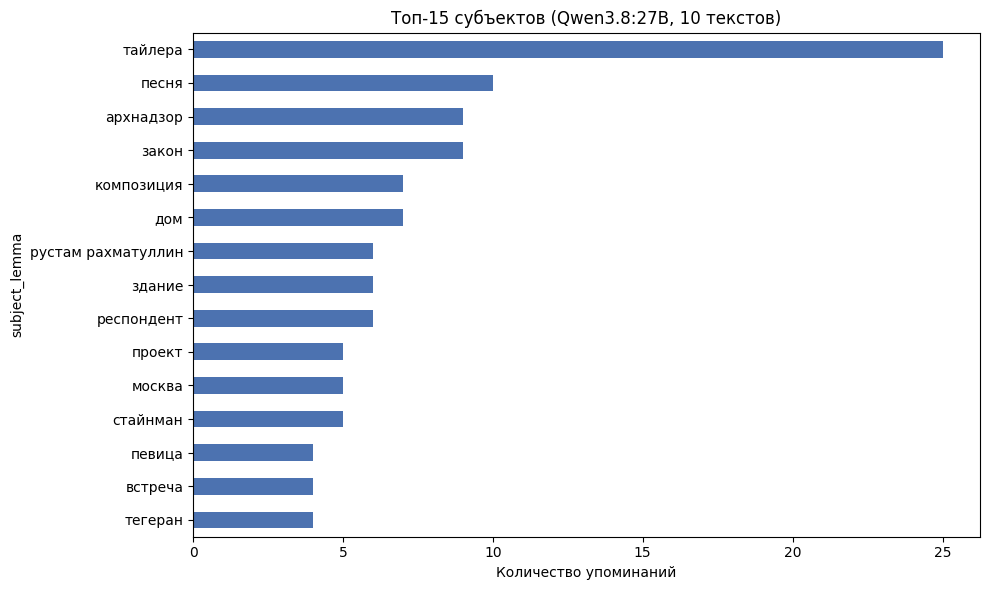

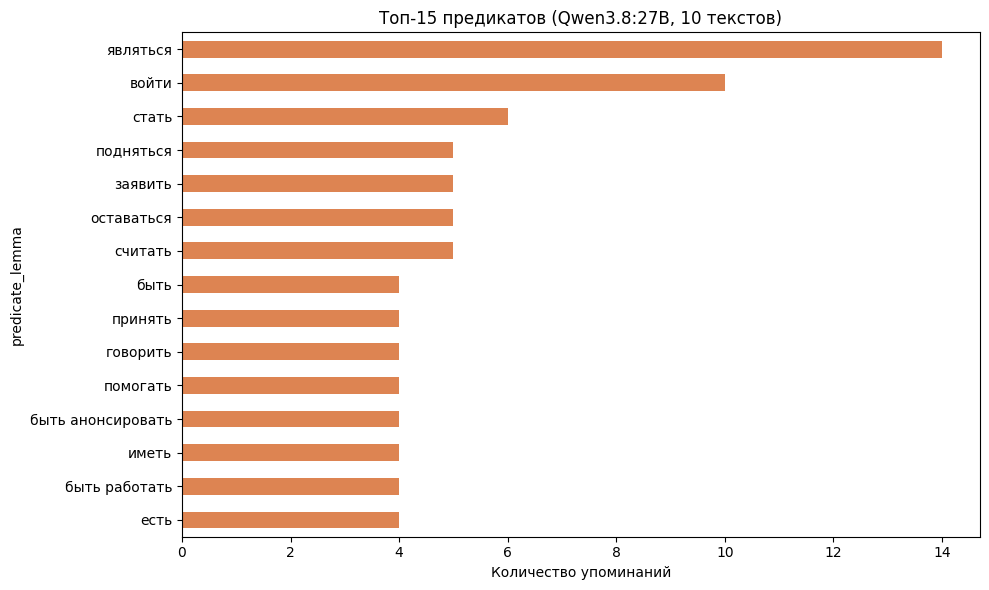

In [109]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
inf["subject_lemma"].value_counts().head(15).plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Количество упоминаний")
ax.set_title("Топ-15 субъектов (Qwen3.8:27B, 10 текстов)")
plt.tight_layout()
plt.savefig("top_subjects_v2.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
inf["predicate_lemma"].value_counts().head(15).plot(kind="barh", ax=ax, color="#DD8452")
ax.invert_yaxis()
ax.set_xlabel("Количество упоминаний")
ax.set_title("Топ-15 предикатов (Qwen3.8:27B, 10 текстов)")
plt.tight_layout()
plt.savefig("top_predicates_v2.png", dpi=150)
plt.show()